# Visualize results: Reizman_Summit and Ahneman (Doyle DFT)

Reads the tables the cluster's chained collection job wrote into
`runs/<tag>/collected/` and draws every figure inline. **Nothing is written to
disk** — no figures, no tables, no export cache.

Same chart style as `compare_featuresets.ipynb` at the repo root: bars grouped
under a bracket per block, one colour per ligand feature set, labels clipped at
a hard zero floor (a negative R² is printed at the baseline).

Blocks:

* **Reizman_Summit** — our seven feature sets, with condition one-hots and the
  three continuous conditions.
* **Ahneman (Doyle DFT), added** — Doyle's 120 RF descriptors plus our ligand
  feature set (`doyle_full_*`).
* **Ahneman (Doyle DFT), in place** — Doyle's 56 condition descriptors plus our
  ligand feature set instead of their 64 ligand descriptors (`doyle_cond_*`).
* **Doyle ligand + condition OHE** — `doyle_ligand_cond_ohe`.

Three charts: pooled 5-fold CV R², matched IID vs LOLO R², and ARD feature
importance. Needs `numpy pandas matplotlib`, no PyTorch.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from IPython.display import display

ROOT = Path.cwd().resolve()          # this notebook lives in gp_collab_hub/
sys.path.insert(0, str(ROOT))
from gpc.results import method_label, rank_features

# ---- Editable ----
RUNS = {
    'reizman_summit':    {'runs': ROOT / 'runs' / 'reizman_summit_20261001',
                          'bundle': ROOT / 'datasets' / 'reizman_summit' / 'inputs'},
    'ahneman_doyle_dft': {'runs': ROOT / 'runs' / 'ahneman_doyle_dft_v2_20261001',
                          'bundle': ROOT / 'datasets' / 'ahneman_doyle_dft' / 'inputs'},
}
# -------------------


def canonical_method(method):
    # Matched IID is iid_stratified_<n groups>; 5-fold CV is the stratified 5-fold.
    if method.startswith('iid_stratified_'):
        return 'iid_matched'
    return {'kfold_stratified_5': 'kfold'}.get(method, method)


summaries = []
for run, info in RUNS.items():
    summary = pd.read_csv(info['runs'] / 'collected' / 'summary.csv')
    meta = json.loads(next(info['runs'].glob('*__*/meta.json')).read_text())
    expected = len(meta['config']['run']['models']) * len(meta['config']['run']['methods'])
    done = summary[['model', 'method']].drop_duplicates().shape[0]
    print(f"{run}: complete={done == expected}  {done}/{expected} tasks")
    summaries.append(summary.assign(run=run, method=summary.method.map(canonical_method),
                                    r2=summary.pooled_r2, rmse=summary.pooled_rmse))
results = pd.concat(summaries, ignore_index=True)

reizman_summit: complete=True  28/28 tasks
ahneman_doyle_dft: complete=True  72/72 tasks


In [2]:
# Bar labels and colours are keyed by the LIGAND feature set, so the same
# representation has the same colour in every block.
LIGAND_LABELS = {
    'group_ohe': 'OHE', 'selected_2': 'Selected-2',
    'vbur_min_vmin': r'$V_\mathrm{bur}$ min + $V_\mathrm{min}$',
    'vbur_boltz_vmin': r'$V_\mathrm{bur}$ boltz + $V_\mathrm{min}$',
    'selected_5': 'Selected-5', 'pc_top': 'PC top', 'pc_scores': 'PC scores',
    'kraken_all': 'All Kraken', 'doyle_only': 'Doyle only', 'doyle_ligand': 'Doyle ligand',
}
OURS = ['group_ohe', 'selected_2', 'vbur_min_vmin', 'vbur_boltz_vmin',
        'selected_5', 'pc_top', 'pc_scores']

# Each block: (bracket label, run, [(model key, ligand feature set)]).
BLOCKS = [
    ('Reizman_Summit', 'reizman_summit', [(x, x) for x in OURS]),
    ('Ahneman (Doyle DFT)\nadded: Doyle 120 + ours', 'ahneman_doyle_dft',
     [('doyle_full', 'doyle_only')] + [(f'doyle_full_{x}', x) for x in OURS + ['kraken_all']]),
    ('Ahneman (Doyle DFT)\nin place: Doyle cond. 56 + ours', 'ahneman_doyle_dft',
     [(f'doyle_cond_{x}', x) for x in OURS + ['kraken_all']]),
    ('Doyle ligand\n+ cond. OHE', 'ahneman_doyle_dft', [('doyle_ligand_cond_ohe', 'doyle_ligand')]),
]

missing = [(run, model) for _, run, bars in BLOCKS for model, _ in bars
           if results[(results.run == run) & (results.model == model)].empty]
if missing:
    print('Missing feature sets (will show as gaps in the charts below):', missing)

rows = [{'block': label.replace('\n', ' '), 'featureset': LIGAND_LABELS[key],
          **results[(results.run == run) & (results.model == model)]
              .set_index('method').r2.to_dict()}
         for label, run, bars in BLOCKS for model, key in bars]
display(pd.DataFrame(rows).set_index(['block', 'featureset'])
        [['lolo', 'iid_matched', 'kfold', 'kfold_5']].round(4))

lolo  \
block                                              featureset                                          
Reizman_Summit                                     OHE                                        0.6452   
                                                   Selected-2                                 0.6695   
                                                   $V_\mathrm{bur}$ min + $V_\mathrm{min}$    0.4628   
                                                   $V_\mathrm{bur}$ boltz + $V_\mathrm{min}$  0.6666   
                                                   Selected-5                                 0.5474   
                                                   PC top                                     0.0690   
                                                   PC scores                                  0.7004   
Ahneman (Doyle DFT) added: Doyle 120 + ours        Doyle only                                -0.0657   
                                                   OHE                                       -0.0657   
                                                   Selected-2                                -0.0657   
                                                   $V_\mathrm{bur}$ min + $V_\mathrm{min}$   -0.0657   
                                                   $V_\mathrm{bur}$ boltz + $V_\mathrm{min}$ -0.0657   
                                                   Selected-5                                -0.0657   
                                                   PC top                                    -0.0657   
                                                   PC scores                                 -0.0657   
                                                   All Kraken                                -0.0657   
Ahneman (Doyle DFT) in place: Doyle cond. 56 + ... OHE                                        0.6763   
                                                   Selected-2                                 0.7471   
                                                   $V_\mathrm{bur}$ min + $V_\mathrm{min}$    0.6418   
                                                   $V_\mathrm{bur}$ boltz + $V_\mathrm{min}$  0.6548   
                                                   Selected-5                                 0.6676   
                                                   PC top                                    -0.0652   
                                                   PC scores                                  0.6469   
                                                   All Kraken                                -0.0657   
Doyle ligand + cond. OHE                           Doyle ligand                              -0.0657   

                                                                                              iid_matched  \
block                                              featureset                                               
Reizman_Summit                                     OHE                                             0.9092   
                                                   Selected-2                                      0.9095   
                                                   $V_\mathrm{bur}$ min + $V_\mathrm{min}$         0.8943   
                                                   $V_\mathrm{bur}$ boltz + $V_\mathrm{min}$       0.9076   
                                                   Selected-5                                      0.9111   
                                                   PC top                                          0.8858   
                                                   PC scores                                       0.9116   
Ahneman (Doyle DFT) added: Doyle 120 + ours        Doyle only                                      0.8606   
                                                   OHE                                             0.8606   
                                                   Selected-2                           

In [3]:
# x positions for each block's bars. Bars sit edge-to-edge inside a block;
# blocks are separated by group_gap. Returns (positions, bounds): positions is
# one array of x-coordinates per block, bounds is the (left, right) span of each
# block, for draw_group_brackets below.
def grouped_bar_positions(group_sizes, bar_width=0.8, group_gap=0.9):
    positions, bounds, cursor = [], [], 0.0
    for size in group_sizes:
        group = cursor + bar_width * np.arange(size)
        positions.append(group)
        bounds.append((group[0] - bar_width / 2, group[-1] + bar_width / 2))
        cursor = group[-1] + bar_width + group_gap
    return positions, bounds


# A square bracket under each (left, right) span in `bounds`, with labels[i]
# centered beneath it. y/tick are axes-fraction units while x stays in data
# units, so the bracket sits at a fixed visual depth regardless of the data.
def draw_group_brackets(ax, bounds, labels, y=-0.30, tick=0.035, fontsize=9):
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for (left, right), label in zip(bounds, labels):
        ax.plot([left, left, right, right], [y + tick, y, y, y + tick],
                 color='0.3', linewidth=0.9, transform=trans, clip_on=False)
        ax.text((left + right) / 2, y - tick * 1.6, label, transform=trans,
                 ha='center', va='top', fontsize=fontsize)


# Labels at the value's own height when >= 0, and at the zero baseline when
# negative, so the number is still shown though the bar is clipped at 0.
def label_bars(ax, bars, values, fmt='%.2f', fontsize=7, pad_points=2):
    for bar, value in zip(bars, values):
        if not np.isfinite(value):
            continue
        y = value if value >= 0 else 0.0
        ax.annotate(fmt % value, xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, pad_points), textcoords='offset points',
                    ha='center', va='bottom', fontsize=fontsize)


# Hard floor at 0, always.
def set_bar_ylim(ax, values, top_margin=1.15):
    hi = max(0.0, float(np.nanmax(values)))
    ax.set_ylim(0, hi * top_margin)


def block_values(method, metric='r2'):
    # One array of values per block, in BLOCKS order.
    out = []
    for _, run, bars in BLOCKS:
        part = results[(results.run == run) & (results.method == method)].set_index('model')
        out.append(part.reindex([m for m, _ in bars])[metric].to_numpy())
    return out


METHOD_COLORS = {'lolo': '#c0392b', 'iid_matched': '#5b8db8', 'kfold': '#a8c8e0'}

# Okabe-Ito for the five shared with compare_featuresets.ipynb, then extras.
FEATURESET_COLORS = {
    'group_ohe': '#E69F00', 'selected_2': '#0072B2', 'selected_5': '#009E73',
    'pc_top': '#D55E00', 'pc_scores': '#CC79A7',
    'vbur_min_vmin': '#56B4E9', 'vbur_boltz_vmin': '#8C6BB1',
    'kraken_all': '#999999', 'doyle_only': '#4D4D4D', 'doyle_ligand': '#A6761D',
}

# One colour per series in the feature-importance panels.
SERIES_COLORS = {'Reizman_Summit': 'tab:blue', 'Ahneman (Doyle DFT), in place': 'tab:green',
                 'Ahneman (Doyle DFT), added': 'tab:red'}

TICK_ANGLE = 35   # shared x-tick rotation for both bar charts

### 5-fold CV by feature set

One bar per feature set, coloured by the ligand feature set it carries.
`TITLE` and `YLABEL` are editable.

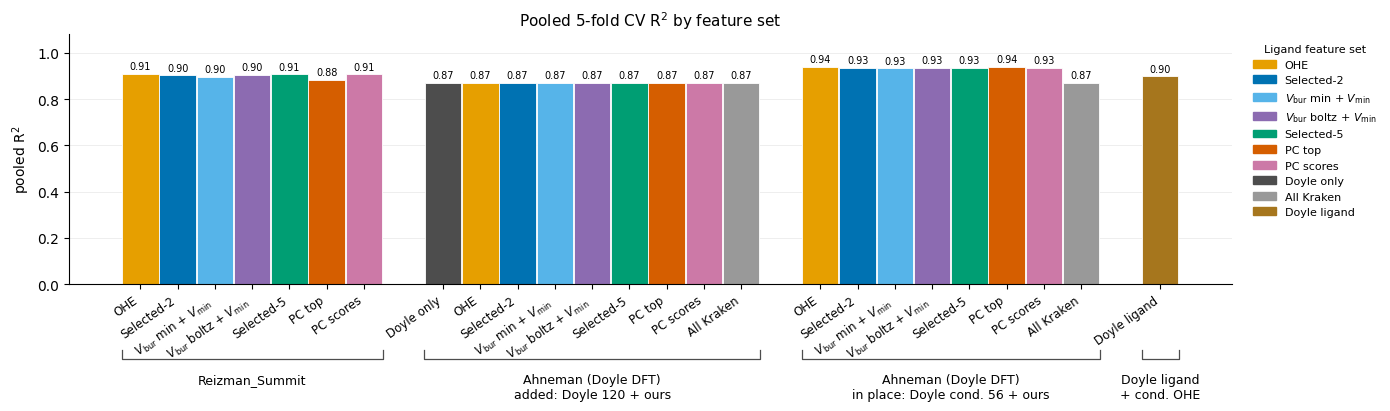

In [4]:
# ---- Editable ----
TITLE = 'Pooled 5-fold CV R$^2$ by feature set'
YLABEL = 'pooled R$^2$'
# -------------------

METRIC = 'r2'
METHOD = 'kfold'

plt.close('all')

positions, bounds = grouped_bar_positions([len(bars) for _, _, bars in BLOCKS],
                                          bar_width=0.8, group_gap=0.9)
values = block_values(METHOD, METRIC)

fig, ax = plt.subplots(figsize=(14, 5))
tick_labels, seen = [], []
for group_pos, vals, (_, _, bars) in zip(positions, values, BLOCKS):
    keys = [k for _, k in bars]
    bars_drawn = ax.bar(group_pos, vals, width=0.78, edgecolor='white', linewidth=0.6,
                        color=[FEATURESET_COLORS[k] for k in keys])
    label_bars(ax, bars_drawn, vals, fontsize=7)
    tick_labels += [LIGAND_LABELS[k] for k in keys]
    seen += [k for k in keys if k not in seen]

ax.set_xticks(np.concatenate(positions))
ax.set_xticklabels(tick_labels, rotation=TICK_ANGLE, ha='right', fontsize=8.5)
draw_group_brackets(ax, bounds, [label for label, _, _ in BLOCKS])

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=FEATURESET_COLORS[k]) for k in seen]
ax.legend(legend_handles, [LIGAND_LABELS[k] for k in seen], title='Ligand feature set',
          fontsize=8, title_fontsize=8, frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))

ax.set(xlabel='', ylabel=YLABEL)
ax.set_title(TITLE, fontsize=11)
set_bar_ylim(ax, np.concatenate(values))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.subplots_adjust(bottom=0.42)

display(fig)
plt.close(fig)

### Matched IID vs LOLO by feature set

Each feature set gets two bars, `iid_matched` and `lolo`. `TITLE2` and
`YLABEL2` are editable.

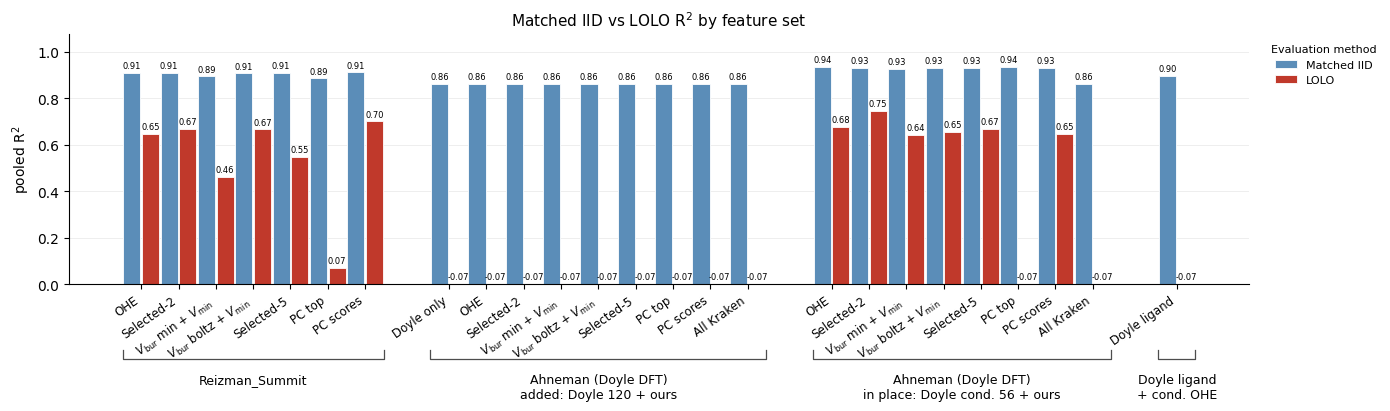

In [5]:
# ---- Editable ----
TITLE2 = 'Matched IID vs LOLO R$^2$ by feature set'
YLABEL2 = 'pooled R$^2$'
# --------------------

METRIC2 = 'r2'
METHODS2 = ['iid_matched', 'lolo']      # draw order = legend order

plt.close('all')

bar_width = 0.36
pair_width = bar_width * len(METHODS2)
positions2, bounds2 = grouped_bar_positions([len(bars) for _, _, bars in BLOCKS],
                                            bar_width=pair_width, group_gap=0.9)

fig, ax = plt.subplots(figsize=(14, 5))
all_values2 = []
for i, method in enumerate(METHODS2):
    xs = np.concatenate([group_pos - pair_width / 2 + bar_width * (i + 0.5)
                         for group_pos in positions2])
    heights = np.concatenate(block_values(method, METRIC2))
    all_values2.append(heights)
    bars_drawn = ax.bar(xs, heights, width=bar_width * 0.92, edgecolor='white', linewidth=0.6,
                        color=METHOD_COLORS[method], label=method_label(method))
    label_bars(ax, bars_drawn, heights, fontsize=6)

ax.set_xticks(np.concatenate(positions2))
ax.set_xticklabels([LIGAND_LABELS[k] for _, _, bars in BLOCKS for _, k in bars],
                   rotation=TICK_ANGLE, ha='right', fontsize=8.5)
draw_group_brackets(ax, bounds2, [label for label, _, _ in BLOCKS])

ax.set(xlabel='', ylabel=YLABEL2)
ax.set_title(TITLE2, fontsize=11)
set_bar_ylim(ax, np.concatenate(all_values2))
ax.legend(title='Evaluation method', fontsize=8, title_fontsize=8, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.subplots_adjust(bottom=0.42)

display(fig)
plt.close(fig)

### Feature importance (ARD), by ligand feature set

One panel per ligand feature set, one colour per series, sharing a feature
axis. Reizman_Summit and Ahneman's in-place sections carry the same ligand
descriptors, so their bars line up feature for feature. Only the ligand block
is ranked (`ligand_only=True`), so continuous conditions and Doyle's condition
descriptors are excluded.

The added (`doyle_full_*`) series is off by default: those LOLO fits collapsed
to the training mean with every lengthscale at its starting value, so their
ranking carries no information. Add it to `IMPORTANCE_SERIES` to see that.

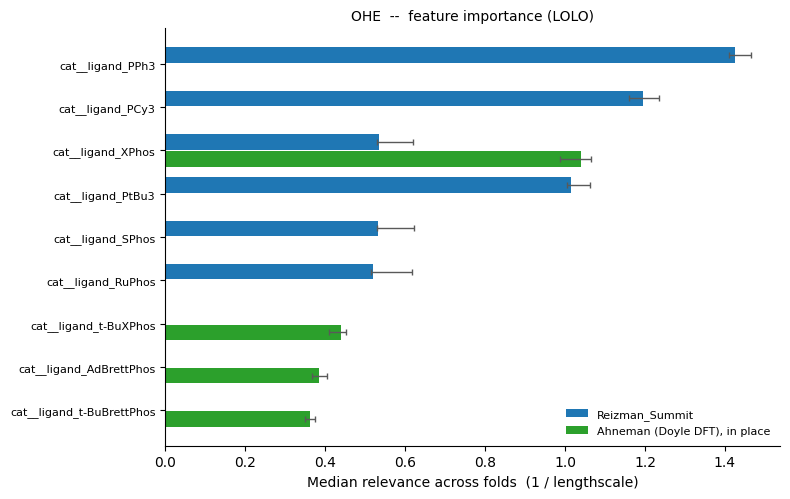

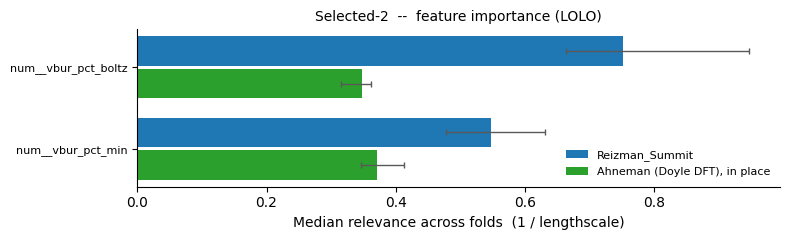

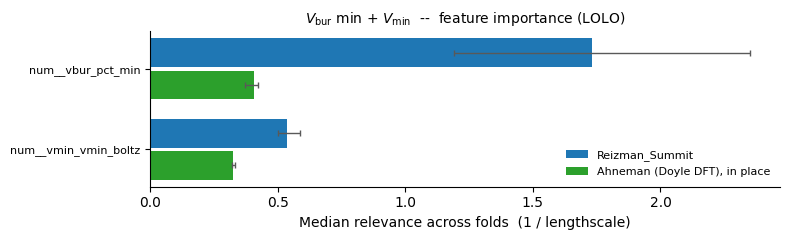

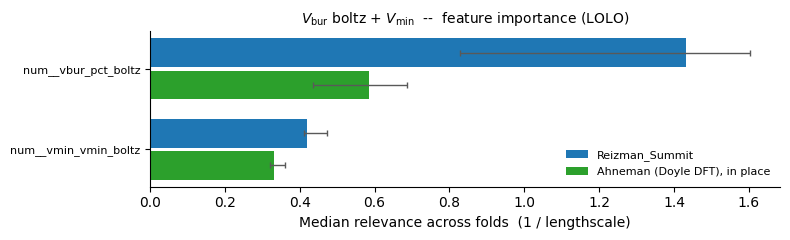

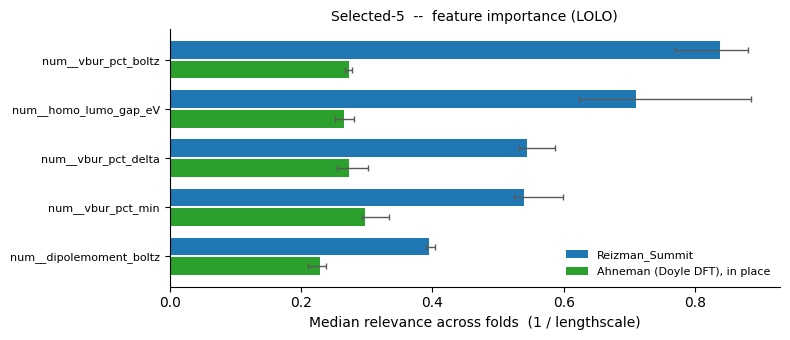

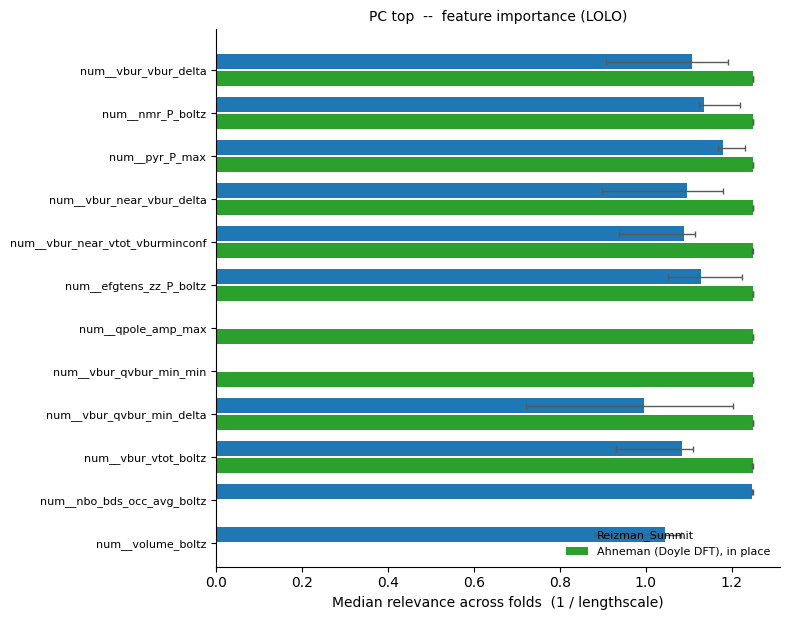

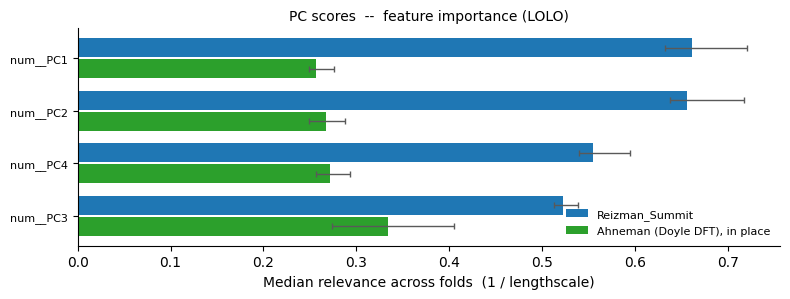

In [6]:
# ---- Editable ----
TOP_N = 10
IMPORTANCE_METHOD = 'lolo'
IMPORTANCE_FEATURESETS = OURS
IMPORTANCE_SERIES = {                       # series label -> (run, model key template)
    'Reizman_Summit': ('reizman_summit', '{x}'),
    'Ahneman (Doyle DFT), in place': ('ahneman_doyle_dft', 'doyle_cond_{x}'),
    # 'Ahneman (Doyle DFT), added': ('ahneman_doyle_dft', 'doyle_full_{x}'),
}
# -------------------

plt.close('all')

for featureset in IMPORTANCE_FEATURESETS:
    parts, unavailable = [], []
    for series, (run, template) in IMPORTANCE_SERIES.items():
        model_key = template.format(x=featureset)
        try:
            ranked = rank_features(RUNS[run]['runs'], RUNS[run]['bundle'], model_key,
                                   method=IMPORTANCE_METHOD, ligand_only=True, top=TOP_N)
        except (ValueError, FileNotFoundError):
            unavailable.append(series)
            continue
        parts.append(ranked.assign(series=series))

    if not parts:
        print(f'{LIGAND_LABELS[featureset]}: no ARD lengthscales available for any series')
        continue

    table = pd.concat(parts, ignore_index=True)
    feature_order = (table.groupby('feature')['median_relevance'].max()
                     .sort_values(ascending=False).index.tolist())
    y_index = {feature: i for i, feature in enumerate(feature_order)}

    series_present = list(dict.fromkeys(table.series))
    bar_height = 0.8 / len(series_present)

    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.4 * len(feature_order) + 1.5)))
    for i, series in enumerate(series_present):
        part = table[table.series == series]
        y = (np.array([y_index[f] for f in part.feature])
             + (i - (len(series_present) - 1) / 2) * bar_height)
        error = np.vstack([(part.median_relevance - part.relevance_q1).to_numpy(),
                           (part.relevance_q3 - part.median_relevance).to_numpy()])
        ax.barh(y, part.median_relevance.to_numpy(), height=bar_height * 0.9, xerr=error,
                color=SERIES_COLORS.get(series, 'tab:gray'),
                error_kw={'ecolor': '0.35', 'elinewidth': 1, 'capsize': 2},
                label=series)

    ax.set_yticks(range(len(feature_order)))
    ax.set_yticklabels(feature_order, fontsize=8)
    ax.invert_yaxis()
    ax.set(xlabel='Median relevance across folds  (1 / lengthscale)')
    ax.set_title(f'{LIGAND_LABELS[featureset]}  --  feature importance '
                 f'({method_label(IMPORTANCE_METHOD)})', fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()

    display(fig)
    plt.close(fig)
    if unavailable:
        print(f'{LIGAND_LABELS[featureset]}: no ARD lengthscales for', unavailable)